# Computing the collision probabilities of different unique DNA molecules into the same consensus molecule via equal cuts and equal tagging

### How to compute required input

#### (optional) 0. Sort the files in case they are not sorted
This might not be needed for the immediate next step but might be useful for exploring some example cases

```
# in case you want to resort the BAM file
samtools sort -@ 7 P_6_2_J_1.sorted.bam -o P_6_2_J_1.resorted.bam --write-index
```

#### 1. Starting from a BAM file you can run this 
This will report for each read which is the starting and end position of the alignment.

```
for file in $(ls *.sorted.bam); do
  sample=${file%.bam}
  echo "$sample"

  samtools view -@ 15 ${sample}.bam | \
  awk '
  function cigar_len(cigar,   len,op,total) {
      total=0
      while (match(cigar, /[0-9]+[MIDNSHP=X]/)) {
          len=substr(cigar, RSTART, RLENGTH-1)
          op=substr(cigar, RSTART+RLENGTH-1, 1)
          if (op ~ /[MDN=X]/) total += len
          cigar=substr(cigar, RSTART+RLENGTH)
      }
      return total
  }

  BEGIN{OFS="\t"}

  {
    chr=$3
    pos=$4
    cigar=$6

    if (chr=="*" || cigar=="*") next

    len = cigar_len(cigar)
    end = pos + len - 1

    print $1, chr, pos, end
  }' | gzip > ${sample}.read_coords.tsv.gz

done
```


#### 2. Merge the information of each pair of reads and report how many times a given set of cuts is unique
```
for file in $(ls *_2.sorted.bam | cut -d '.' -f1); do
echo $file;
python /data/bbg/projects/prominent/protocols/paper_figures/supplementary_analysis/UMIcollisions/compute_unique_cuts_freq.py $file /data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/2026-03-17_tws_idt ;
done;
```

Example of output:

```
$ zcat SC001_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
repeats	frequency
1	46353191
2	2430718
3	254679
4	37477
5	7193
6	1687
7	485
8	191
9	80
10	39
11	19
12	9
14	6
16	3
13	2
18	1
17	1
```


In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
run = "/data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/2026-03-17_tws_idt"

In [26]:
cord_blood_samples_list = [# "SC003_B1_1_H_1", "SC002_B1_1_H_1", "SC001_B1_1_H_1",
                           "SC003_B1_1_H_2", "SC002_B1_1_H_2", "SC001_B1_1_H_2"]
reference_sample = "SC001_B1_1_H_2"


In [4]:
# sample = [
# #             "TS_DNA_TS_FEZ_TS_Adapters_idt_v2",
# #             "TS_DNA_IDT_EZF",
# #             "TS_DNA_75uM_IDT_idt_v3_speedvac",
#             "Cord_Blood_3_Ultrashear",
#             # "Cord_Blood_3_IDT_EZF_FPGUDG_338",
#             # "Cord_Blood_3_IDT_EZF_354",
#             "Cord_Blood_3_bufferR1_1",
#             # "Cord_Blood_3_3uM_KapaPCR",
#             # "Cord_Blood_3_3uM_IDTPCR",
#             # "Cord_Blood_3_15uM_KapaPCR",
#         ]
# sample = "Cord_Blood_3_bufferR1_1"
# # sample = "Cord_Blood_3_Ultrashear"
# run = "/data/bbg/nobackup2/prominent/duplex_seq_tests/technology_tests/rosana_data/2025-11-03.tests/2025-11-04_deepUMIcaller"

## Read cut frequency files and plot them

In [75]:
all_counts_df = pd.DataFrame()
for file in os.listdir(f"{run}/processing_files/sortbamamfiltered/"):
    if file.endswith(".sorted.read_coords.cuts_freq.tsv.gz"):
        print(file)
        sample = file.split('.')[0]
        sample_counts = pd.read_csv(f"{run}/processing_files/sortbamamfiltered/{file}", sep="\t")
        sample_counts["sample"] = sample
        sample_counts["relative_frequency"] = sample_counts["frequency"] / sample_counts["frequency"].sum()
        sample_counts["expected_poisson_cuts"] = (sample_counts["relative_frequency"] * sample_counts["repeats"]).sum()
        all_counts_df = pd.concat([all_counts_df, sample_counts], ignore_index=True)


SC002_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC001_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC003_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC001_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz
SC002_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz
SC003_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz


In [76]:
all_counts_df.head(20)

,repeats,frequency,sample,relative_frequency,expected_poisson_cuts
0,1,57106533,SC002_B1_1_H_2,9.348416e-01,1.075648
1,2,3463947,SC002_B1_1_H_2,5.670528e-02,1.075648
2,3,424075,SC002_B1_1_H_2,6.942164e-03,1.075648
3,4,70498,SC002_B1_1_H_2,1.154062e-03,1.075648
4,5,15412,SC002_B1_1_H_2,2.522965e-04,1.075648
5,6,4239,SC002_B1_1_H_2,6.939300e-05,1.075648
6,7,1288,SC002_B1_1_H_2,2.108473e-05,1.075648
7,8,502,SC002_B1_1_H_2,8.217807e-06,1.075648
8,9,176,SC002_B1_1_H_2,2.881144e-06,1.075648
9,10,76,SC002_B1_1_H_2,1.244130e-06,1.075648


In [11]:
# all_counts_df[all_counts_df["repeats"] > 20]

In [18]:
# sns.boxplot(data=all_counts_df,
#              x="repeats",
#              y="relative_frequency",             
#              )
# sns.stripplot(data=all_counts_df,
#              x="repeats",
#              y="relative_frequency",             
#              hue="sample",
#              dodge=False
#              )
# plt.yscale("log")
# plt.xlabel("Number of reads with identical cut sites")
# plt.ylabel("Relative frequency")
# plt.title("Frequency of identical cut sites across samples")
# plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

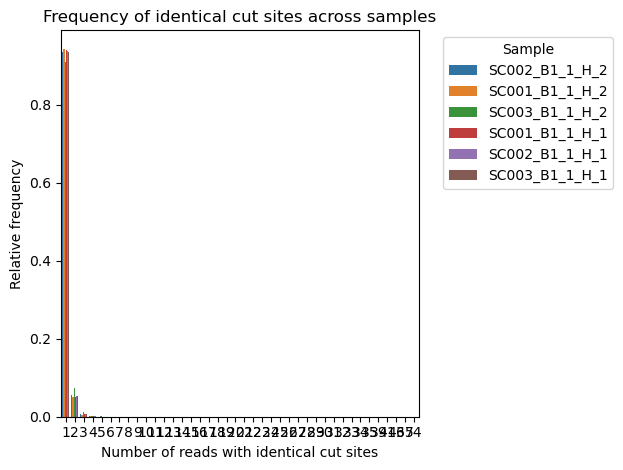

In [77]:
sns.barplot(data=all_counts_df,
             x="repeats",
             y="relative_frequency",             
             hue="sample",
             dodge=True)
# plt.yscale("log")
plt.xlabel("Number of reads with identical cut sites")
plt.ylabel("Relative frequency")
plt.title("Frequency of identical cut sites across samples")
plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
all_counts_df["total_fragments"] = all_counts_df["repeats"] * all_counts_df["frequency"]
all_counts_df["repeated"] = all_counts_df["repeats"] > 1
repeated_frequency = all_counts_df.groupby(by = ["sample", "repeated"])["total_fragments"].sum()
repeated_frequency

sample          repeated
SC001_B1_1_H_1  False       72605095
                True         9930665
SC001_B1_1_H_2  False       46353191
                True         5828011
SC002_B1_1_H_1  False       91013953
                True        13236728
SC002_B1_1_H_2  False       57106533
                True         8601399
SC003_B1_1_H_1  False       97322864
                True        14360079
SC003_B1_1_H_2  False       68727524
                True        15478474
Name: total_fragments, dtype: int64

In [21]:
per_sample_repeated_frequency = repeated_frequency.unstack(fill_value=0)
per_sample_repeated_frequency = per_sample_repeated_frequency.div(per_sample_repeated_frequency.sum(axis=1), axis=0)
per_sample_repeated_frequency

repeated,False,True
sample,,
SC001_B1_1_H_1,0.879680,0.120320
SC001_B1_1_H_2,0.888312,0.111688
SC002_B1_1_H_1,0.873030,0.126970
SC002_B1_1_H_2,0.869096,0.130904
SC003_B1_1_H_1,0.871421,0.128579
SC003_B1_1_H_2,0.816183,0.183817


## UMI counts

In [27]:
umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{reference_sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()
umi_counts_data.head()

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,cummulative_fraction
0,GAAGGAAG,4033017,74489,437966,0.086753,0.081374,0.086753
1,ATCCAGAG,4021147,63139,439242,0.086498,0.081611,0.173251
2,ACTAGGAG,3647794,58423,403599,0.078467,0.074988,0.251718
3,TTGCGAAG,2776906,50690,309339,0.059734,0.057475,0.311452
4,CTGTTGAC,2575421,44369,283122,0.055399,0.052604,0.366851


In [28]:
# major_freq = umi_counts_data[umi_counts_data["cummulative_fraction"] <= 0.99]
# minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > 0.99].sum()

major_freq_df = umi_counts_data.iloc[:100,:]
minor_freq_df = umi_counts_data.iloc[100:,:]
minor_freq = minor_freq_df.sum()
minor_freq["umi"] = str(len(minor_freq_df)) + 'umis'
minor_freq["cummulative_fraction"] = 1
minor_freq

umi                             13055umis
raw_observations                   403039
raw_observations_with_errors        56034
unique_observations                267944
fraction_raw_observations        0.008671
fraction_unique_observations     0.049797
cummulative_fraction                    1
dtype: object

In [29]:
merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
merged_umis = merged_umis.reset_index()
merged_umis.head()

,index,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,cummulative_fraction
0,0,GAAGGAAG,4033017,74489,437966,0.086753,0.081374,0.086753
1,1,ATCCAGAG,4021147,63139,439242,0.086498,0.081611,0.173251
2,2,ACTAGGAG,3647794,58423,403599,0.078467,0.074988,0.251718
3,3,TTGCGAAG,2776906,50690,309339,0.059734,0.057475,0.311452
4,4,CTGTTGAC,2575421,44369,283122,0.055399,0.052604,0.366851


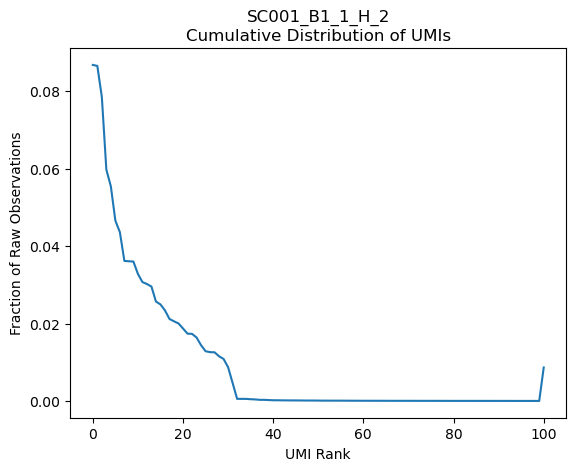

In [31]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{reference_sample}\nCumulative Distribution of UMIs")
plt.show()

In [35]:
merged_umis.iloc[:32]["fraction_unique_observations"].values

array([0.081374, 0.081611, 0.074988, 0.057475, 0.052604, 0.043412,
       0.042489, 0.033713, 0.034425, 0.034388, 0.031485, 0.029353,
       0.02871, 0.028479, 0.024458, 0.02325, 0.022311, 0.019952, 0.019424,
       0.018779, 0.017762, 0.016308, 0.016376, 0.015387, 0.013856,
       0.012449, 0.012224, 0.01188, 0.01104, 0.010672, 0.008346, 0.004443],
      dtype=object)

In [56]:
import numpy as np

In [81]:
unique_tags_number = 32
umi_tag_probabilities = merged_umis["fraction_unique_observations"].iloc[:unique_tags_number].values
umi_tag_probabilities = umi_tag_probabilities / umi_tag_probabilities.sum()
umi_tag_probabilities

array([0.08717805325131266, 0.08743195742980407, 0.08033656766546357,
       0.061574441598289315, 0.05635601436861959, 0.046508389015483875,
       0.04551955544270926, 0.03611760155899309, 0.036880385420115,
       0.03684074637115221, 0.033730688016044175, 0.031446621735269006,
       0.03075775934383447, 0.030510283119228907, 0.026202482690055852,
       0.02490832130770294, 0.023902346524566038, 0.021375089321775877,
       0.020809429379820298, 0.020118424337090476, 0.019028886153437403,
       0.017471178661764283, 0.017544028805804017, 0.016484487740284954,
       0.01484428817374331, 0.013336932987509416, 0.013095884716789711,
       0.012727348694000471, 0.011827435149980236, 0.01143318731164756,
       0.008941283855229623, 0.004759899852478459], dtype=object)

In [82]:
tag_probabilities_assume_random_side = np.matmul(umi_tag_probabilities.reshape(-1, 1), umi_tag_probabilities.reshape(1, -1)).flatten()
tag_probabilities_assume_random_side

array([0.007600012968688705, 0.007622147840681961, 0.007003585573967466,
       ..., 5.442082659806981e-05, 4.255961570347551e-05,
       2.2656646605624456e-05], shape=(1024,), dtype=object)

In [83]:
probability_of_same_tag_2_frag = np.sum(tag_probabilities_assume_random_side ** 2) 
probability_of_same_tag_2_frag

0.0021576988898600056

Effective barcode diversity

In [86]:
D_eff = 1 / probability_of_same_tag_2_frag
D_eff

463.45669671493476

In [84]:
lam = 1.07
mu = (lam**2 / 2) * probability_of_same_tag_2_frag

P_collision = 1 - np.exp(-mu)
P_collision

np.float64(0.00123441221517262)

## Duplex UMI counts

In [51]:
# umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.duplex_umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()
umi_counts_data.head()

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,ATCCAGAG-GAAGGAAG,363874,11691,33709,0.008365,0.007463,0.007160,0.008365
1,GAAGGAAG-ATCCAGAG,363535,11823,33620,0.008357,0.007443,0.007160,0.016722
2,ACTAGGAG-GAAGGAAG,331779,10792,31044,0.007627,0.006873,0.006575,0.024349
3,GAAGGAAG-ACTAGGAG,324716,10723,30608,0.007465,0.006776,0.006575,0.031814
4,ACTAGGAG-ATCCAGAG,317810,9113,30362,0.007306,0.006722,0.006539,0.039120


In [52]:
for threshold in [0.95, 0.99, 0.995, 0.999]:
    major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= threshold]
    minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > threshold]
    print(f"Threshold: {threshold}: major: {len(major_freq_df)}, minor: {len(minor_freq_df)}")
    print()


major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= 0.999]
minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > 0.999]
# major_freq_df = umi_counts_data.iloc[:100000,:]
# minor_freq_df = umi_counts_data.iloc[100000:,:]

print(len(major_freq_df), len(minor_freq_df))

minor_freq = minor_freq_df[['raw_observations', 'raw_observations_with_errors',
                            'unique_observations', 'fraction_raw_observations',
                            'fraction_unique_observations', 'fraction_unique_observations_expected',]].sum()
minor_freq["umi"] = str(len(minor_freq_df)) + ' umis'
minor_freq["cummulative_fraction"] = 1
minor_freq

Threshold: 0.95: major: 862, minor: 175447

Threshold: 0.99: major: 7528, minor: 168781

Threshold: 0.995: major: 28005, minor: 148304

Threshold: 0.999: major: 132878, minor: 43431

132878 43431


raw_observations                            43431.0
raw_observations_with_errors                    0.0
unique_observations                         43431.0
fraction_raw_observations                  0.000998
fraction_unique_observations               0.009615
fraction_unique_observations_expected      0.004836
umi                                      43431 umis
cummulative_fraction                              1
dtype: object

In [53]:
merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
merged_umis = merged_umis.reset_index()
merged_umis.head()

,index,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,0,ATCCAGAG-GAAGGAAG,363874,11691,33709,0.008365,0.007463,0.00716,0.008365
1,1,GAAGGAAG-ATCCAGAG,363535,11823,33620,0.008357,0.007443,0.00716,0.016722
2,2,ACTAGGAG-GAAGGAAG,331779,10792,31044,0.007627,0.006873,0.006575,0.024349
3,3,GAAGGAAG-ACTAGGAG,324716,10723,30608,0.007465,0.006776,0.006575,0.031814
4,4,ACTAGGAG-ATCCAGAG,317810,9113,30362,0.007306,0.006722,0.006539,0.03912


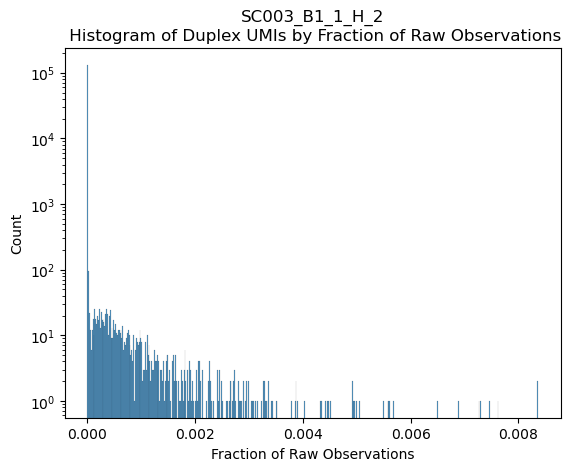

In [54]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.histplot(data=merged_umis, x="fraction_raw_observations", bins=500)
plt.xlabel("Fraction of Raw Observations")
plt.title(f"{sample}\n Histogram of Duplex UMIs by Fraction of Raw Observations")
# plt.xscale("log")
plt.yscale("log")
plt.show()

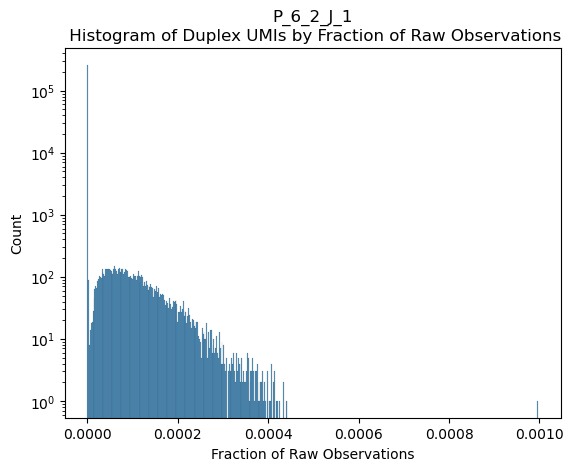

In [34]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.histplot(data=merged_umis, x="fraction_raw_observations", bins=500)

plt.xlabel("Fraction of Raw Observations")
plt.title(f"{sample}\n Histogram of Duplex UMIs by Fraction of Raw Observations")

plt.yscale("log")
plt.show()

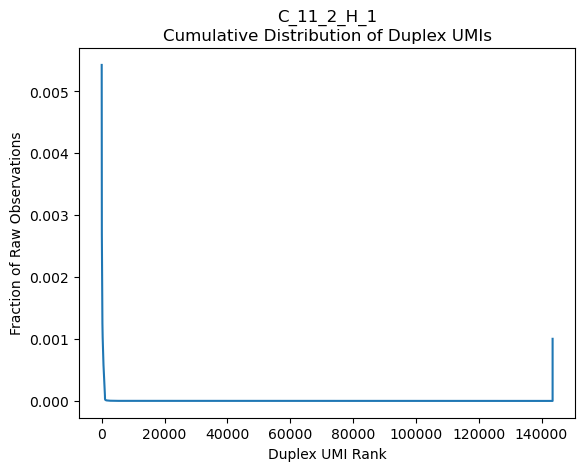

In [28]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("Duplex UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of Duplex UMIs")
plt.show()

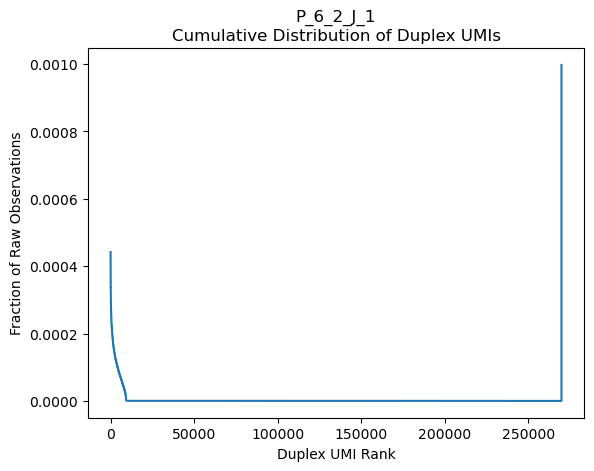

In [20]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("Duplex UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of Duplex UMIs")
plt.show()

# REMOVE

## TEST -All molecules

In [ ]:
data = pd.read_csv(f"{run}/processing_files/sortbamamfiltered/{sample}.sorted.read_coords.head.tsv.gz",
                   sep="\t",
                   header=None)

In [ ]:
data.columns = ["READ_NAME", "CHROM", "START", "END"]
data.head(20)

,READ_NAME,CHROM,START,END
0,SC001_B1_1_H_2_chr1:1090,chr1,777639,777770
1,SC001_B1_1_H_2_chr1:1090,chr1,777586,777717
2,SC001_B1_1_H_2_chr1:1153,chr1,788768,788899
3,SC001_B1_1_H_2_chr1:1153,chr1,788738,788864
4,SC001_B1_1_H_2_chr1:1156,chr1,789009,789140
5,SC001_B1_1_H_2_chr1:1156,chr1,789241,789372
6,SC001_B1_1_H_2_chr1:1168,chr1,790199,790330
7,SC001_B1_1_H_2_chr1:1168,chr1,790018,790149
8,SC001_B1_1_H_2_chr1:1176,chr1,790940,791071
9,SC001_B1_1_H_2_chr1:1176,chr1,790850,790981


In [ ]:
merged_cuts = (
    data
    .groupby(["READ_NAME", "CHROM"])
    .agg(
        START_first=("START", "min"),
        END_first=("END", "min"),
        START_last=("START", "max"),
        END_last=("END", "max"),
    )
    .reset_index()
)

In [ ]:
first_in_pair = data.sort_values(by = ["READ_NAME", "CHROM", "START"]).drop_duplicates(subset=["READ_NAME"], keep='first')
last_in_pair = data.sort_values(by = ["READ_NAME", "CHROM", "START"]).drop_duplicates(subset=["READ_NAME"], keep='last')

In [ ]:
merged_cuts = first_in_pair.merge(last_in_pair, on=["READ_NAME", 'CHROM'], suffixes=("_first", "_last"))
merged_cuts

NameError: name 'first_in_pair' is not defined

In [ ]:
identical_cuts_size = merged_cuts.groupby(["CHROM", "START_first", "END_first", "START_last", "END_last"]).size()
frequency_identical_cuts_size = identical_cuts_size.to_frame().reset_index().rename(columns={0: "count"})
frequency_identical_cuts_size
# frequency_identical_cuts_size = identical_cuts_size.value_counts().to_frame().reset_index().rename(columns={"index": "repeats", 0: "count"})
# frequency_identical_cuts_size

,CHROM,START_first,END_first,START_last,END_last,count
0,chr1,777586,777717,777639,777770,1
1,chr1,788738,788864,788768,788899,1
2,chr1,789009,789140,789241,789372,1
3,chr1,790018,790149,790199,790330,1
4,chr1,790850,790981,790940,791071,1
...,...,...,...,...,...,...
468653,chr1,11210632,11210763,11210965,11211096,1
468654,chr1,11210632,11210763,11211009,11211140,1
468655,chr1,11210632,11210763,11211089,11211220,1
468656,chr1,11210657,11210747,11210887,11211017,1


In [ ]:
# merged_cuts[merged_cuts.duplicated(subset = ["START_first", "END_first", "START_last", "END_last"], keep=False)]

In [ ]:
frequency_identical_cuts_size["count"].value_counts().to_frame(
    name = 'frequency').reset_index().rename(
        columns={"count": "repeats"}).to_csv(
            f"{run}/processing_files/sortbamamfiltered/{sample}.sorted.read_coords.cuts_freq.tsv.gz",
            sep="\t", index=False, compression="gzip")

,repeats,frequency
0,1,440519
1,2,25405
2,3,2351
3,4,314
4,5,58
5,6,6
6,7,4
7,8,1
